# Building a Mini AI Roadmap with RICE Prioritisation

**Module 04 — Business Case & AI Project Management — Exercise 02**

Apply the RICE framework (Reach, Impact, Confidence, Effort) to prioritise a backlog of six user stories for an AI customer-support chatbot, then assemble a 6-month phased roadmap and confront the RICE ranking with real-world dependency constraints. The framework is the same one introduced in [`notes/05_roadmap_and_prioritization.md`](../notes/05_roadmap_and_prioritization.md), and the PoC → MVP → Scaling structure follows [`notes/06_product_lifecycle_poc_to_scale.md`](../notes/06_product_lifecycle_poc_to_scale.md).

## Scenario — ChatGenius Inc.

A startup launching an AI customer-support chatbot with three business goals:
- Cut support cost by 40%.
- Lift CSAT from 7.2 to 8.5.
- Scale ticket volume from 500/month to 5000/month.

Timeline: 6 months split into three phases — **PoC (M1-2)**, **MVP (M3-4)**, **Scaling (M5-6)**.

## Backlog

Six user stories, with estimates produced jointly by Product and Engineering:

| ID | Title | Reach | Impact | Conf. | Effort | Phase | Depends on |
|---|---|---:|---:|---:|---:|---|---|
| US-001 | Intent Classification Engine | 5000 | 3 | 80% | 13 | PoC | — |
| US-002 | FAQ Knowledge Base | 4500 | 2 | 90% | 8 | PoC | — |
| US-003 | Smart Escalation System | 2000 | 3 | 85% | 5 | PoC | US-001 |
| US-004 | Context Management | 3000 | 2 | 70% | 8 | MVP | US-001 |
| US-005 | CRM Integration | 3500 | 2 | 75% | 8 | MVP | US-001 |
| US-006 | Active Learning Pipeline | 3000 | 2 | 60% | 13 | Scaling | US-001, US-004 |

**RICE formula** (as in [`notes/05`](../notes/05_roadmap_and_prioritization.md)):

$$\text{RICE} = \frac{\text{Reach} \times \text{Impact} \times (\text{Confidence}/100)}{\text{Effort}}$$

Reach in users/month, Impact on a 0.25-3 scale (3 = massive), Confidence as a percentage, Effort in story points.

## Part 1 — RICE prioritisation

Encode the backlog, compute the RICE score, rank.

The ranking is interesting on its own but does not yet produce an executable plan: it ignores dependencies, team velocity, and the phase split imposed by the lifecycle (PoC → MVP → Scaling). Part 2 confronts the ranking with those constraints.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

user_stories = [
    {'id': 'US-001', 'title': 'Intent Classification Engine',
     'description': 'NLP model classifying user intents at >85% accuracy',
     'reach': 5000, 'impact': 3, 'confidence': 80, 'effort': 13,
     'phase': 'PoC', 'dependencies': []},
    {'id': 'US-002', 'title': 'FAQ Knowledge Base',
     'description': 'Semantic store of 100+ FAQs with retrieval',
     'reach': 4500, 'impact': 2, 'confidence': 90, 'effort': 8,
     'phase': 'PoC', 'dependencies': []},
    {'id': 'US-003', 'title': 'Smart Escalation System',
     'description': 'Hand-off to human agent on low confidence or detected frustration',
     'reach': 2000, 'impact': 3, 'confidence': 85, 'effort': 5,
     'phase': 'PoC', 'dependencies': ['US-001']},
    {'id': 'US-004', 'title': 'Context Management',
     'description': 'Multi-turn memory across 10+ exchanges',
     'reach': 3000, 'impact': 2, 'confidence': 70, 'effort': 8,
     'phase': 'MVP', 'dependencies': ['US-001']},
    {'id': 'US-005', 'title': 'CRM Integration',
     'description': 'Pull customer profile from CRM, personalise responses',
     'reach': 3500, 'impact': 2, 'confidence': 75, 'effort': 8,
     'phase': 'MVP', 'dependencies': ['US-001']},
    {'id': 'US-006', 'title': 'Active Learning Pipeline',
     'description': 'Weekly retraining with drift detection',
     'reach': 3000, 'impact': 2, 'confidence': 60, 'effort': 13,
     'phase': 'Scaling', 'dependencies': ['US-001', 'US-004']},
]

df = pd.DataFrame(user_stories)
df['rice_score'] = (df['reach'] * df['impact'] * df['confidence'] / 100) / df['effort']
df['priority_rank'] = df['rice_score'].rank(ascending=False, method='dense').astype(int)
df_sorted = df.sort_values('rice_score', ascending=False).reset_index(drop=True)

print('=' * 80)
print('RICE PRIORITISATION')
print('=' * 80)
print('Formula: RICE = (Reach * Impact * Confidence%) / Effort')
print()
display_cols = ['priority_rank', 'id', 'title', 'reach', 'impact',
                'confidence', 'effort', 'rice_score', 'phase']
print(df_sorted[display_cols].to_string(index=False))

print('\nTop 3 by RICE:')
for _, row in df_sorted.head(3).iterrows():
    deps = ', '.join(row['dependencies']) if row['dependencies'] else 'none'
    print(f"  {row['priority_rank']}. {row['title']:<32s} "
          f"RICE={row['rice_score']:.0f}  deps={deps}")

RICE PRIORITISATION
Formula: RICE = (Reach * Impact * Confidence%) / Effort

 priority_rank     id                        title  reach  impact  confidence  effort  rice_score   phase
             1 US-003      Smart Escalation System   2000       3          85       5 1020.000000     PoC
             2 US-002           FAQ Knowledge Base   4500       2          90       8 1012.500000     PoC
             3 US-001 Intent Classification Engine   5000       3          80      13  923.076923     PoC
             4 US-005              CRM Integration   3500       2          75       8  656.250000     MVP
             5 US-004           Context Management   3000       2          70       8  525.000000     MVP
             6 US-006     Active Learning Pipeline   3000       2          60      13  276.923077 Scaling

Top 3 by RICE:
  1. Smart Escalation System          RICE=1020  deps=US-001
  2. FAQ Knowledge Base               RICE=1012  deps=none
  3. Intent Classification Engine     RICE=92

**Reading the ranking.** US-003 (Smart Escalation) tops the list at RICE ≈ 1020 — small effort, high impact, decent confidence. But it depends on US-001 (Intent Classification), which is itself a high-RICE foundational item. Pure RICE order is *not* execution order: dependency edges in the backlog graph constrain the schedule. This is the standard gotcha from [`notes/05`](../notes/05_roadmap_and_prioritization.md) — RICE ranks initiatives, but a plan needs the topological order on top of the ranking.

## Part 2 — Phased roadmap

Three phases aligned with the PoC → MVP → Scaling lifecycle. Each phase carries its own milestone, success KPIs, and top risks. Effort sums per phase let us check that the 6-month plan is feasible at a reasonable team velocity.

In [2]:
roadmap = {
    'PoC (M1-2)': {
        'stories': ['US-001', 'US-002', 'US-003'],
        'milestone': 'Core chatbot working prototype',
        'kpis': ['Intent accuracy > 85%',
                 'Containment rate > 40%',
                 'Response time < 2s'],
        'risks': ['Training-data quality',
                  'Accuracy below target'],
    },
    'MVP (M3-4)': {
        'stories': ['US-004', 'US-005'],
        'milestone': 'Production-ready beta',
        'kpis': ['CSAT > 7.5',
                 'Escalation rate < 30%',
                 'CRM sync success > 95%'],
        'risks': ['CRM API stability',
                  'User adoption'],
    },
    'Scaling (M5-6)': {
        'stories': ['US-006'],
        'milestone': '5K tickets/month capability',
        'kpis': ['40% cost reduction',
                 'Model staleness < 7 days',
                 'Uptime > 99.5%'],
        'risks': ['Infrastructure scaling',
                  'Model drift'],
    },
}

print('=' * 80)
print('6-MONTH PHASED ROADMAP')
print('=' * 80)

total_effort = 0
for phase, details in roadmap.items():
    phase_stories = df[df['id'].isin(details['stories'])]
    effort = phase_stories['effort'].sum()
    total_effort += effort
    print(f"\n{phase}")
    print(f"  Milestone: {details['milestone']}")
    print(f"  Stories:   {', '.join(details['stories'])}  ({effort} pts)")
    print(f"  KPIs:      {' | '.join(details['kpis'])}")
    print(f"  Top risks: {' | '.join(details['risks'])}")

velocity = total_effort / 6
print(f"\nTotal effort: {total_effort} story points over 6 months")
print(f"Required velocity: {velocity:.1f} pts/month")
print(f"Team sizing (~3-5 pts/person/month): {np.ceil(velocity/5):.0f}-{np.ceil(velocity/3):.0f} engineers")

print('\nRICE vs dependency constraint inside the PoC:')
print('  RICE order:        US-003 -> US-001 -> US-002')
print('  Dependency order:  US-001 first (needed by US-003 and downstream MVP / Scaling)')
print('  Execution order:   US-001, then US-002 and US-003 in parallel once foundation is stable')

6-MONTH PHASED ROADMAP

PoC (M1-2)
  Milestone: Core chatbot working prototype
  Stories:   US-001, US-002, US-003  (26 pts)
  KPIs:      Intent accuracy > 85% | Containment rate > 40% | Response time < 2s
  Top risks: Training-data quality | Accuracy below target

MVP (M3-4)
  Milestone: Production-ready beta
  Stories:   US-004, US-005  (16 pts)
  KPIs:      CSAT > 7.5 | Escalation rate < 30% | CRM sync success > 95%
  Top risks: CRM API stability | User adoption

Scaling (M5-6)
  Milestone: 5K tickets/month capability
  Stories:   US-006  (13 pts)
  KPIs:      40% cost reduction | Model staleness < 7 days | Uptime > 99.5%
  Top risks: Infrastructure scaling | Model drift

Total effort: 55 story points over 6 months
Required velocity: 9.2 pts/month
Team sizing (~3-5 pts/person/month): 2-4 engineers

RICE vs dependency constraint inside the PoC:
  RICE order:        US-003 -> US-001 -> US-002
  Dependency order:  US-001 first (needed by US-003 and downstream MVP / Scaling)
  Execution

**Sanity check on velocity.** Total effort is 55 story points spread over 6 months → ~9.2 pts/month. At 3-5 pts/person/month that maps to a 2-3 engineer team. This is consistent with the startup scenario; a single engineer would underdeliver and a 5+ team would be wasting capacity.

The interesting observation: by RICE alone, US-003 should be built first. By dependency, it cannot be. A naive read of the framework would push the team toward US-003 immediately; the right read uses RICE as a *signal* and reconciles it with the dependency graph before committing to sequence.

## Part 3 — Visualisations

Two panels, one figure: the RICE ranking on the left, the 6-month phased timeline on the right. Diamonds mark the three milestone checkpoints.

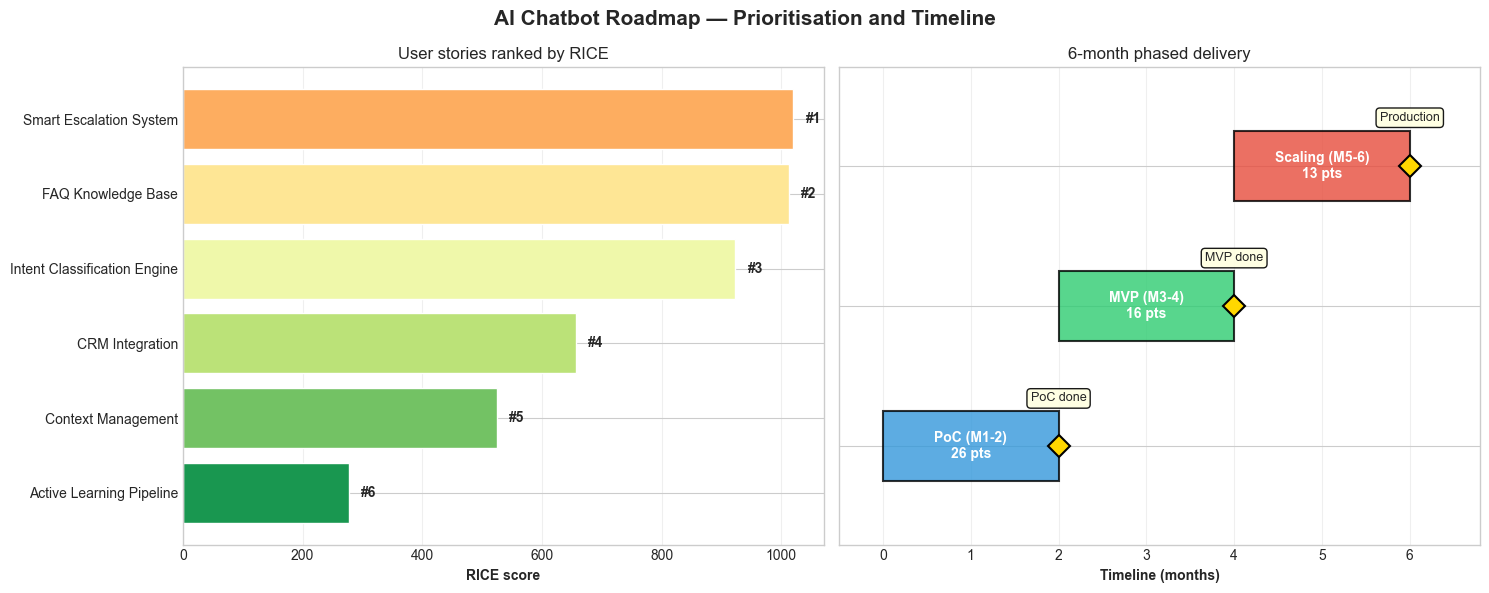

Saved: 02_ex_ai_roadmap_rice_prioritization.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('AI Chatbot Roadmap — Prioritisation and Timeline',
             fontsize=15, fontweight='bold')

# Left: RICE ranking, gradient red (low) to green (high)
colors_rice = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(df_sorted)))
axes[0].barh(df_sorted['title'], df_sorted['rice_score'],
             color=colors_rice, edgecolor='white')
axes[0].set_xlabel('RICE score', fontweight='bold')
axes[0].set_title('User stories ranked by RICE')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)
for i, row in df_sorted.iterrows():
    axes[0].text(row['rice_score'] + max(df_sorted['rice_score']) * 0.02,
                 i, f"#{row['priority_rank']}",
                 va='center', fontweight='bold', fontsize=10)

# Right: Gantt-style phase timeline
phases = list(roadmap.keys())
colors_phase = ['#3498db', '#2ecc71', '#e74c3c']
start_months = [0, 2, 4]
durations = [2, 2, 2]

for i, (phase, start, duration, color) in enumerate(zip(phases, start_months,
                                                        durations, colors_phase)):
    phase_stories = df[df['id'].isin(roadmap[phase]['stories'])]
    effort = phase_stories['effort'].sum()
    axes[1].barh(i, duration, left=start, height=0.5,
                 color=color, alpha=0.8, edgecolor='black', linewidth=1.5)
    axes[1].text(start + duration/2, i, f"{phase}\n{effort} pts",
                 ha='center', va='center', fontweight='bold',
                 fontsize=10, color='white')

axes[1].set_yticks(range(len(phases)))
axes[1].set_yticklabels(['' for _ in phases])
axes[1].set_xlabel('Timeline (months)', fontweight='bold')
axes[1].set_title('6-month phased delivery')
axes[1].set_xlim(-0.5, 6.8)
axes[1].set_ylim(-0.7, len(phases) - 0.3)
axes[1].grid(axis='x', alpha=0.3)

milestones = [(2, 0, 'PoC done'), (4, 1, 'MVP done'), (6, 2, 'Production')]
for month, idx, label in milestones:
    axes[1].plot(month, idx, marker='D', markersize=11, color='gold',
                 markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    axes[1].text(month, idx + 0.32, label, ha='center', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor='lightyellow', edgecolor='black', alpha=0.9))

plt.tight_layout()
plt.savefig('02_ex_ai_roadmap_rice_prioritization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_ex_ai_roadmap_rice_prioritization.png')

## Part 4 — Insights and recommendations

Critical path, go/no-go gates, risk mitigations, success metrics, velocity recap. The framework gave us the ranking; the recommendations turn it into something a team can act on.

In [4]:
print('=' * 80)
print('INSIGHTS AND RECOMMENDATIONS')
print('=' * 80)

print('\nTop 3 by RICE (rationale):')
for _, story in df_sorted.head(3).iterrows():
    print(f"  {story['priority_rank']}. {story['title']:<32s} RICE={story['rice_score']:.0f}")
    print(f"     Reach={story['reach']}, Impact={story['impact']}, "
          f"Confidence={story['confidence']}%, Effort={story['effort']} pts")

print('\nCritical path of development:')
print('  Phase 1 (PoC):    US-001 first — foundation; without it, no Escalation or smart FAQ matching.')
print('                    US-002 and US-003 in parallel after US-001 is stable.')
print('  Phase 2 (MVP):    US-004 and US-005 — personalisation; CSAT > 7.5 hinges on these.')
print('  Phase 3 (Scaling): US-006 — automation and drift handling; the 40% cost cut depends on this.')

print('\nGo / no-go checkpoints:')
print('  Month 2 (PoC review):')
print('    - Intent accuracy must clear 85% on a held-out test set.')
print('    - Containment > 40% in real user testing.')
print('    - If miss: revisit training data first; rule-based fallback as last resort.')
print('  Month 4 (MVP review):')
print('    - CSAT on the beta cohort > 7.0 (target 7.5).')
print('    - Escalation rate < 35% (target < 30%).')
print('    - If miss: iterate on UX and content before pushing for scale.')

print('\nRisk mitigations by phase:')
print('  PoC:     thin training data -> synthetic data augmentation, careful labelling.')
print('  MVP:     CRM API instability -> caching layer + graceful degradation.')
print('  Scaling: model drift -> auto-rollback + alerting; cost overruns -> usage caps.')

print('\nSuccess metrics by phase:')
print('  PoC (M2):     Intent > 85% | Containment > 40% | Latency < 2s')
print('  MVP (M4):     CSAT > 7.5 | Escalation < 30% | CRM sync > 95%')
print('  Scale (M6):   5K tickets/month | -40% support cost | Uptime > 99.5%')

print('\nVelocity recap:')
print(f'  Total effort:      {total_effort} story points')
print(f'  Timeline:          6 months')
print(f'  Required velocity: {velocity:.1f} pts/month')
print(f'  Team:              2-3 engineers at 3-5 pts/person/month')

INSIGHTS AND RECOMMENDATIONS

Top 3 by RICE (rationale):
  1. Smart Escalation System          RICE=1020
     Reach=2000, Impact=3, Confidence=85%, Effort=5 pts
  2. FAQ Knowledge Base               RICE=1012
     Reach=4500, Impact=2, Confidence=90%, Effort=8 pts
  3. Intent Classification Engine     RICE=923
     Reach=5000, Impact=3, Confidence=80%, Effort=13 pts

Critical path of development:
  Phase 1 (PoC):    US-001 first — foundation; without it, no Escalation or smart FAQ matching.
                    US-002 and US-003 in parallel after US-001 is stable.
  Phase 2 (MVP):    US-004 and US-005 — personalisation; CSAT > 7.5 hinges on these.
  Phase 3 (Scaling): US-006 — automation and drift handling; the 40% cost cut depends on this.

Go / no-go checkpoints:
  Month 2 (PoC review):
    - Intent accuracy must clear 85% on a held-out test set.
    - Containment > 40% in real user testing.
    - If miss: revisit training data first; rule-based fallback as last resort.
  Month 4 (MVP

## Critical reading

Some observations on the framework as applied here, not just on the output.

**RICE is a ranking, not a schedule.** US-003 wins on RICE because it is small, high-impact, and depends on a feature (US-001) that is itself already in the PoC phase. Dropped into an automated scheduler that respected only RICE, US-003 would be scheduled first and immediately blocked. The right read is the one in [`notes/05`](../notes/05_roadmap_and_prioritization.md): RICE produces a *prioritised backlog*; the schedule emerges from RICE plus dependencies plus phase constraints plus velocity. Confusing the two is one of the recurring failure modes when teams adopt RICE for the first time.

**Confidence is doing more work than it looks.** US-006 (Active Learning Pipeline) is rated at 60% confidence — the lowest in the backlog — because the team cannot yet know what production telemetry will be available, what drift cadence the chatbot will actually exhibit, or whether weekly retraining is the right cadence at all. The RICE score reflects this with a meaningful penalty (its numerator is multiplied by 0.6 instead of 0.8-0.9). This is the framework working: low-confidence items get demoted, which matches the intuition that uncertain bets should not consume early-phase capacity. The deeper point is that confidence is the place where the *unknown unknowns* enter the framework, and it deserves more discussion than reach and impact, which are usually easier to estimate.

**The 6-month split assumes uniform velocity that won't hold in practice.** 55 points / 6 months ≈ 9.2 pts/month is an honest planning average, but real velocity is uneven: the PoC ramps up slowly because the team is learning the data and the stack; the MVP runs faster because the foundation is in place; Scaling slows down again because operational concerns (drift, latency, observability) eat capacity that pure feature work doesn't. A realistic plan front-loads slack into the PoC and Scaling phases.

**RICE silences the cost asymmetry that matters most for chatbots.** The framework treats Impact as a single 0.25-3 number. But the impact of US-003 (Smart Escalation) is asymmetric: when the bot gets a complex case wrong, it can either escalate (small cost) or hallucinate confidently (legal risk, as seen in the Air Canada case in exercise 01). A single Impact number cannot capture that asymmetry. In practice, for any customer-facing AI feature, the right complement to RICE is a separate *downside risk* score — what's the cost of this feature behaving badly? — and items with high downside should require additional governance gates regardless of RICE rank.

**Cross-phase dependencies create hidden risk.** US-006 (Active Learning Pipeline) depends on US-001 (PoC) and US-004 (MVP). If US-004 slips by even two weeks, US-006 — already the lowest-confidence item — gets squeezed at the end of the timeline. The plan as drawn has zero buffer between MVP completion and Scaling start. A more defensive version would either move some of US-006's design work into the MVP phase (decoupling the dependency) or buy a buffer week into Month 4.

**On what success would actually look like for this roadmap.** The three business goals (40% cost reduction, CSAT 7.2 → 8.5, 500 → 5000 tickets/month) are each addressable by different parts of the plan: the cost reduction comes mostly from US-001 + US-002 (containment), the CSAT lift comes from US-003 + US-004 + US-005 (escalation quality and personalisation), the volume scaling comes from US-006 + infrastructure work that is not even in this backlog (load testing, multi-region deployment, on-call). The fact that the third goal is not fully covered by the user stories listed is itself a finding — the roadmap is necessary but not sufficient for the stated business outcomes.